In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\Uni\Data Analysis\archive\credit_risk_dataset.csv")

## Data Cleaning

In [11]:
df["person_emp_length"] =df["person_emp_length"].fillna(0)
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [12]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,32581.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.658114,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.159669,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           32581 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [14]:
df[df["loan_int_rate"].isna()]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
39,23,71500,RENT,3.0,DEBTCONSOLIDATION,D,30000,NaN,1,0.42,N,4
50,24,78000,RENT,4.0,DEBTCONSOLIDATION,D,30000,NaN,1,0.38,Y,4
57,23,277000,OWN,3.0,PERSONAL,A,35000,NaN,0,0.13,N,4
59,24,12000,OWN,2.0,VENTURE,E,1750,NaN,0,0.15,Y,3
62,26,263000,MORTGAGE,0.0,EDUCATION,B,10000,NaN,1,0.04,N,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32547,53,4888,OWN,0.0,VENTURE,C,1400,NaN,1,0.29,Y,28
32552,65,45900,RENT,2.0,EDUCATION,C,10000,NaN,0,0.22,Y,19
32553,54,20000,RENT,2.0,MEDICAL,C,5000,NaN,0,0.25,N,28
32569,51,60000,MORTGAGE,1.0,PERSONAL,A,7500,NaN,0,0.13,N,23


In [15]:
df["loan_int_rate"].median()

10.99

In [16]:
df["loan_int_rate"] = df["loan_int_rate"].fillna(df["loan_int_rate"].median() + 0.001)
df[df["loan_int_rate"] == 10.919]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length


### Identifying outliers

In [17]:
df = df[df["person_age"] < 100]
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [18]:
df[df["person_emp_length"] > 60]
df = df[df["person_emp_length"] < 60]
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [19]:
df["loan_to_income_ratio"] = df["loan_amnt"] / df["person_income"]
df

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_335428\1223488521.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["loan_to_income_ratio"] = df["loan_amnt"] / df["person_income"]


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_to_income_ratio
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,0.104167
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,0.572917
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,0.534351
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,0.643382
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2,0.252525
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30,0.109434
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19,0.146875
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28,0.460526
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26,0.100000


# Summary Statistics (EDA)

In [35]:
print(f"Total Records: {len(df)}")
print(f"Total Columns: {len(df.columns)}")
print("\nBasic Statistics for Key Variables:")
print(df[['person_age', 'person_income', 'loan_amnt', 'loan_int_rate']].describe())

Total Records: 32574
Total Columns: 20

Basic Statistics for Key Variables:
         person_age  person_income     loan_amnt  loan_int_rate
count  32574.000000   3.257400e+04  32574.000000   32574.000000
mean      27.718426   6.587848e+04   9588.018051      11.009565
std        6.204987   5.253194e+04   6320.249598       3.081663
min       20.000000   4.000000e+03    500.000000       5.420000
25%       23.000000   3.850000e+04   5000.000000       8.490000
50%       26.000000   5.500000e+04   8000.000000      10.991000
75%       30.000000   7.920000e+04  12200.000000      13.110000
max       94.000000   2.039784e+06  35000.000000      23.220000


## Adding new columns
### Risk Level Column

In [20]:
def risk_calc(row):
    if row["loan_status"] == 1: return "High"   
    if row["loan_to_income_ratio"] > 0.5: return "High"
    if 0.3 <= row["loan_to_income_ratio"] <= 0.5: return "Medium"
    if row["loan_to_income_ratio"] < 0.3: return "Low"

In [21]:
df["risk"] = df.apply(risk_calc, axis = 1)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_335428\1596753450.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["risk"] = df.apply(risk_calc, axis = 1)


In [22]:
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_to_income_ratio,risk
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,0.104167,Low
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,0.572917,High
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,0.534351,High
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,0.643382,High
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2,0.252525,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30,0.109434,Low
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19,0.146875,Low
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28,0.460526,High
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26,0.100000,Low


### Job Stability column

In [23]:
df["emp_stability_ratio"] = df["person_emp_length"] / (df["person_age"] - 18)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_335428\527615778.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["emp_stability_ratio"] = df["person_emp_length"] / (df["person_age"] - 18)


### Loan Burden Index

In [24]:
df["loan_burden_index"] = df['loan_to_income_ratio'] * df['loan_int_rate']

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_335428\4022791707.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["loan_burden_index"] = df['loan_to_income_ratio'] * df['loan_int_rate']


## Adding a risk-adjusted income column

In [25]:
df["risk_adjusted_income"] = df.apply(lambda x: x["person_income"] * 0.7 if x["cb_person_default_on_file"] == "Y" else x["person_income"], axis=1)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_335428\559644761.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["risk_adjusted_income"] = df.apply(lambda x: x["person_income"] * 0.7 if x["cb_person_default_on_file"] == "Y" else x["person_income"], axis=1)


In [26]:
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_to_income_ratio,risk,emp_stability_ratio,loan_burden_index,risk_adjusted_income
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,0.104167,Low,1.666667,1.160417,9600.0
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,0.572917,High,0.142857,7.373437,9600.0
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,0.534351,High,0.800000,8.138168,65500.0
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,0.643382,High,1.333333,9.181066,38080.0
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2,0.252525,High,0.666667,1.803030,9900.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30,0.109434,Low,0.025641,1.440151,53000.0
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19,0.146875,Low,0.111111,1.100094,120000.0
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28,0.460526,High,0.063830,5.061184,76000.0
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26,0.100000,Low,0.131579,1.148000,150000.0


### Categorizing Customers


In [27]:
def categorize_customers(row):
    if row["person_age"] < 30 and row["person_income"] > np.median(df["person_income"]) and row["person_emp_length"] <= 10.0: return "Young & High Potential"
    if row["loan_to_income_ratio"] > 0.5 or row["cb_person_default_on_file"] == "Y": return "High Risk"
    if row["person_income"] < 100000 and row["cb_person_cred_hist_length"] >= 10 and row["loan_amnt"] < 100000: return "Financial Giant"
    else: return "Standard"

In [28]:
df["customer_category"] = df.apply(categorize_customers, axis=1)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_335428\297441906.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["customer_category"] = df.apply(categorize_customers, axis=1)


### Credit Maturity Index

In [29]:
df['credit_maturity_index'] = df["cb_person_cred_hist_length"] / df["person_age"]

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_335428\1543272499.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['credit_maturity_index'] = df["cb_person_cred_hist_length"] / df["person_age"]


### Heuristic Scoring (Red-Flag)

In [30]:
df["red-flag"] = ((df["cb_person_default_on_file"] == "Y") & (df["loan_amnt"] > 1000 )).astype(int)
df

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_335428\1386126454.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["red-flag"] = ((df["cb_person_default_on_file"] == "Y") & (df["loan_amnt"] > 1000 )).astype(int)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_to_income_ratio,risk,emp_stability_ratio,loan_burden_index,risk_adjusted_income,customer_category,credit_maturity_index,red-flag
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,0.104167,Low,1.666667,1.160417,9600.0,Standard,0.095238,0
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,0.572917,High,0.142857,7.373437,9600.0,High Risk,0.120000,0
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,0.534351,High,0.800000,8.138168,65500.0,Young & High Potential,0.086957,0
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,0.643382,High,1.333333,9.181066,38080.0,High Risk,0.166667,1
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2,0.252525,High,0.666667,1.803030,9900.0,Standard,0.095238,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30,0.109434,Low,0.025641,1.440151,53000.0,Financial Giant,0.526316,0
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19,0.146875,Low,0.111111,1.100094,120000.0,Standard,0.351852,0
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28,0.460526,High,0.063830,5.061184,76000.0,Financial Giant,0.430769,0
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26,0.100000,Low,0.131579,1.148000,150000.0,Standard,0.464286,0


# 1. CORRELATION MATRIX AND HEATMAP

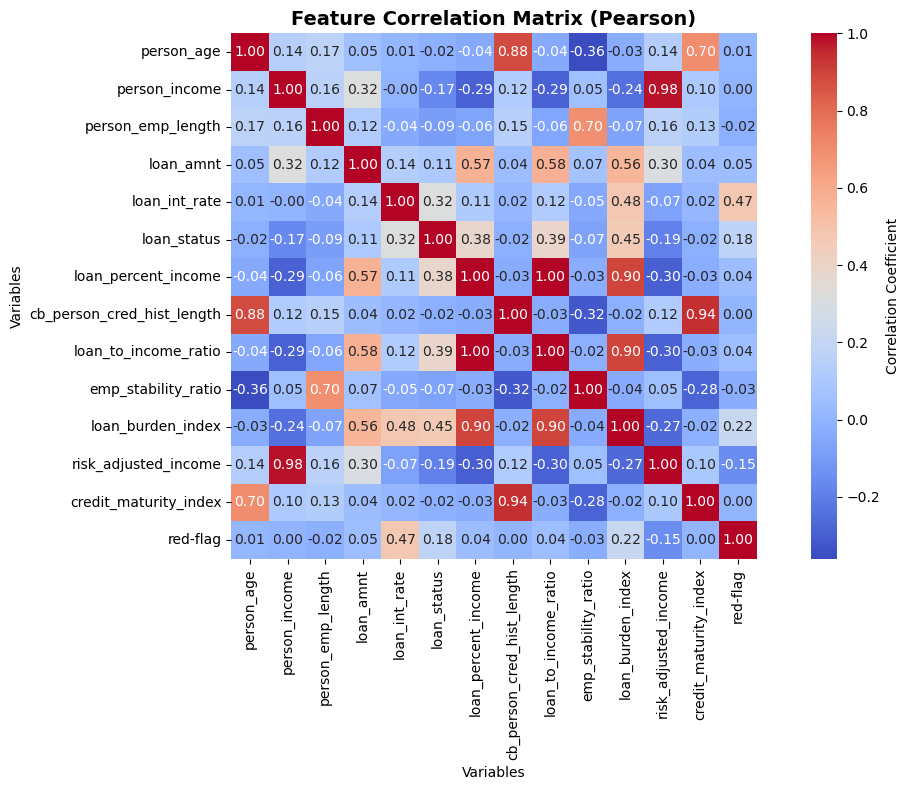


High Correlations (|r| > 0.5):
person_age                  cb_person_cred_hist_length    0.878094
                            credit_maturity_index         0.698616
person_income               risk_adjusted_income          0.980534
person_emp_length           emp_stability_ratio           0.695977
loan_amnt                   loan_percent_income           0.572420
                            loan_to_income_ratio          0.576816
                            loan_burden_index             0.557121
loan_percent_income         loan_amnt                     0.572420
                            loan_to_income_ratio          0.998941
                            loan_burden_index             0.895237
cb_person_cred_hist_length  person_age                    0.878094
                            credit_maturity_index         0.938896
loan_to_income_ratio        loan_amnt                     0.576816
                            loan_percent_income           0.998941
                            lo

In [37]:
# Select only numerical columns (exclude strings and objects)
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

# Create heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Feature Correlation Matrix (Pearson)', fontsize=14, fontweight='bold')
plt.xlabel('Variables')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

# Identify high correlations
print("\nHigh Correlations (|r| > 0.5):")
high_corr = correlation_matrix.unstack()
high_corr = high_corr[high_corr > 0.5]
high_corr = high_corr[high_corr < 1.0]  # Exclude self-correlation (1.0)
print(high_corr)

# 2. RISK LEVEL DISTRIBUTION

risk
Low       24108
High       7163
Medium     1303
Name: count, dtype: int64

Risk Distribution (%):
risk
Low       74.009947
High      21.989931
Medium     4.000123
Name: proportion, dtype: float64


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_335428\3219008619.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='risk', palette=colors, order=['Low', 'Medium', 'High'])


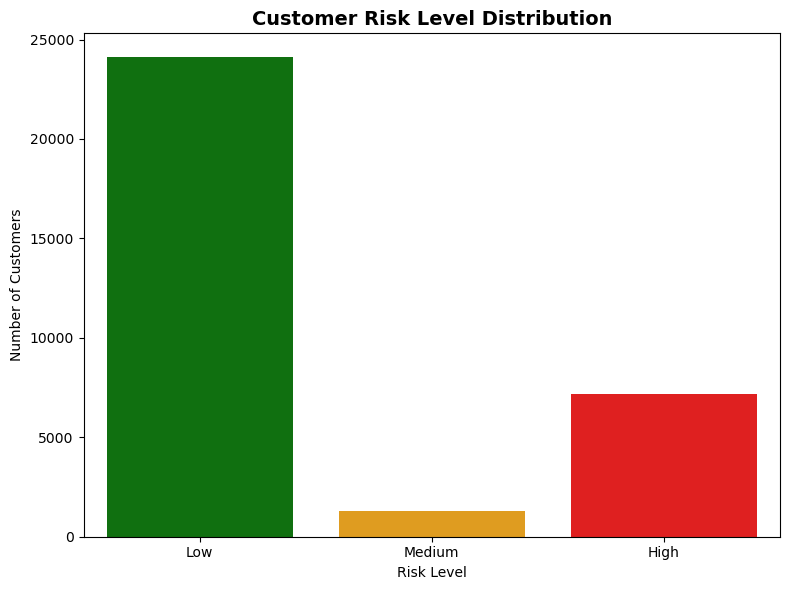

In [39]:
risk_counts = df['risk'].value_counts()
print(risk_counts)
print(f"\nRisk Distribution (%):")
print(df['risk'].value_counts(normalize=True) * 100)

# Create bar plot
plt.figure(figsize=(8, 6))
colors = {'Low': 'green', 'Medium': 'orange', 'High': 'red'}
sns.countplot(data=df, x='risk', palette=colors, order=['Low', 'Medium', 'High'])
plt.title('Customer Risk Level Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Risk Level')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

# 3.AGE-INCOME Relationship

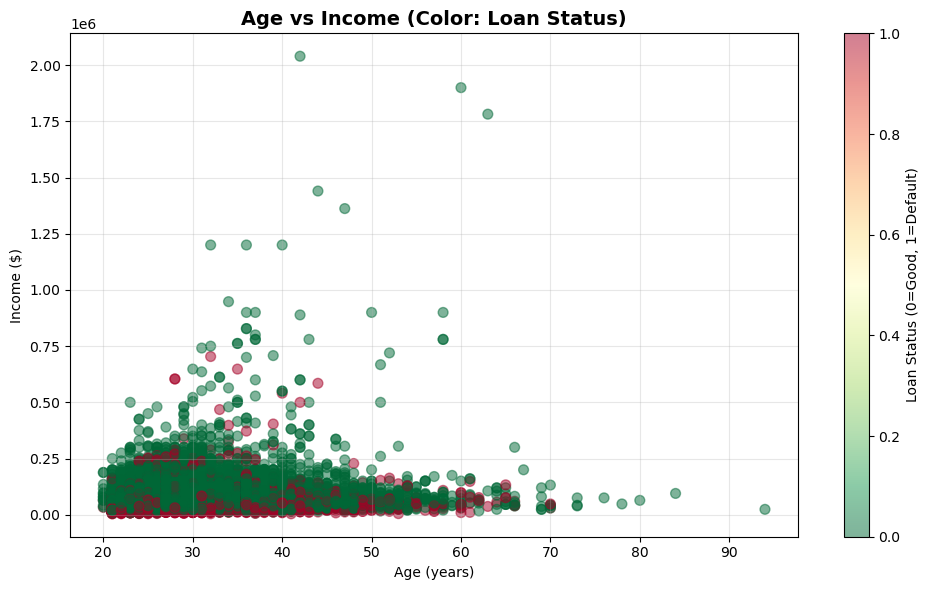

Age-Income Correlation: 0.140


In [41]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['person_age'], df['person_income'], 
                     alpha=0.5, c=df['loan_status'], cmap='RdYlGn_r', s=50)
plt.xlabel('Age (years)')
plt.ylabel('Income ($)')
plt.title('Age vs Income (Color: Loan Status)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Loan Status (0=Good, 1=Default)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate correlation
age_income_corr = df['person_age'].corr(df['person_income'])
print(f"Age-Income Correlation: {age_income_corr:.3f}")

# 4. LOAN INTEREST RATE DISTRIBUTION

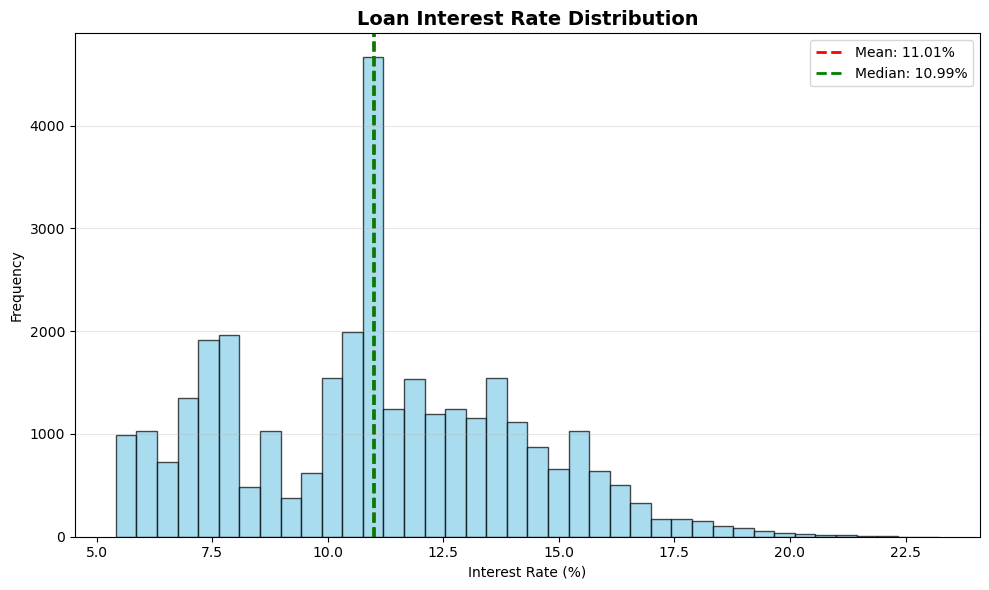

Interest Rate Statistics:
  Min: 5.42%
  Max: 23.22%
  Mean: 11.01%
  Std Dev: 3.08%


In [42]:
plt.figure(figsize=(10, 6))
plt.hist(df['loan_int_rate'], bins=40, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(df['loan_int_rate'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f"Mean: {df['loan_int_rate'].mean():.2f}%")
plt.axvline(df['loan_int_rate'].median(), color='green', linestyle='--', 
            linewidth=2, label=f"Median: {df['loan_int_rate'].median():.2f}%")
plt.xlabel('Interest Rate (%)')
plt.ylabel('Frequency')
plt.title('Loan Interest Rate Distribution', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"Interest Rate Statistics:")
print(f"  Min: {df['loan_int_rate'].min():.2f}%")
print(f"  Max: {df['loan_int_rate'].max():.2f}%")
print(f"  Mean: {df['loan_int_rate'].mean():.2f}%")
print(f"  Std Dev: {df['loan_int_rate'].std():.2f}%")

# 5. LOAN TO INCOME RATIO DISTRIBUTION

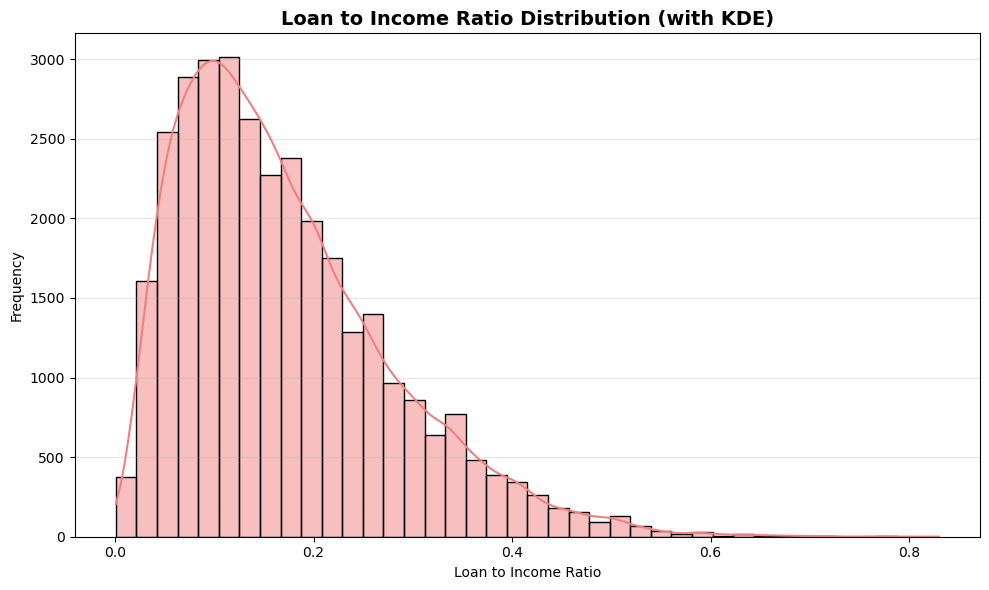


Loan to Income Ratio by Risk Level:
          count      mean       std       min       25%       50%       75%  \
risk                                                                          
High     7163.0  0.251197  0.134649  0.005376  0.138998  0.242424  0.345383   
Low     24108.0  0.136474  0.070397  0.000789  0.080000  0.127660  0.187500   
Medium   1303.0  0.357720  0.052088  0.300000  0.312885  0.345168  0.388889   

             max  
risk              
High    0.830000  
Low     0.299976  
Medium  0.500000  


In [43]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='loan_to_income_ratio', kde=True, bins=40, color='lightcoral')
plt.xlabel('Loan to Income Ratio')
plt.ylabel('Frequency')
plt.title('Loan to Income Ratio Distribution (with KDE)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Relationship with risk level
print("\nLoan to Income Ratio by Risk Level:")
print(df.groupby('risk')['loan_to_income_ratio'].describe())

# ===== RESEARCH QUESTIONS & ANALYSIS =====

## RQ1: Credit History Length vs Default Rate


RQ1: "How does credit history length affect loan default probability?"
    Hypothesis: Customers with longer credit history have lower default rates

RQ2: "Which loan purpose has the highest default risk, and how does it relate to interest rates?"
    Hypothesis: PERSONAL loans have higher default rates & higher interest rates

RQ3: "Which of the three engineered financial features best predicts 
      loan default: employment stability, loan-to-income ratio, 
      or loan burden index?"

Hypothesis: Employment stability is a strong predictor of default, 
            possibly better than loan-to-income alone

ANSWERING RESEARCH QUESTION 1

Default Rate by Credit History Length Groups:
                 Total Customers  Defaults  Default Rate  Default %
cred_hist_group                                                    
0-5 years                  19708      4439      0.225238  22.523848
5-10 years                  9405      1941      0.206380  20.637959
10-15 years                 2320

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_335428\1325654071.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cred_hist_group'] = pd.cut(df['cb_person_cred_hist_length'],
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_335428\1325654071.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rq1_analysis = df.groupby('cred_hist_group')['loan_status'].agg(['count', 'sum', 'mean'])
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_335428\1325654071.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. As

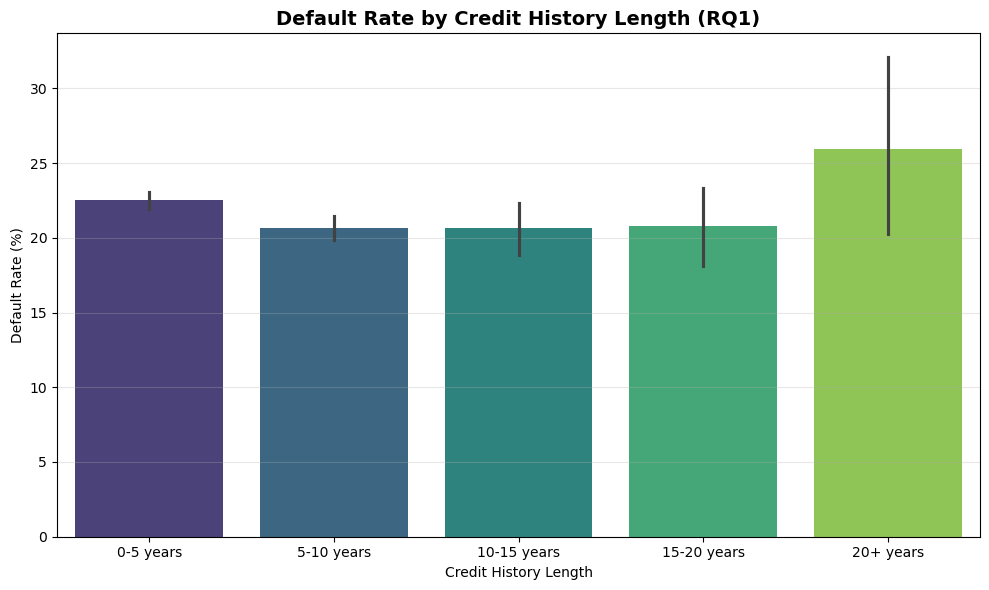


RQ1 Finding (CORRECTED):
→ Default rate DECREASES from 0-5 years to 15-20 years (22.5% → 20.8%)
→ BUT default rate SPIKES UP at 20+ years (25.9%)
→ Hypothesis PARTIALLY REJECTED: The relationship is NON-LINEAR!
→ Longer credit history is protective... UNTIL 20+ years credit history
→ This suggests other factors affect older borrowers differently


In [65]:
print("""
RQ1: "How does credit history length affect loan default probability?"
    Hypothesis: Customers with longer credit history have lower default rates

RQ2: "Which loan purpose has the highest default risk, and how does it relate to interest rates?"
    Hypothesis: PERSONAL loans have higher default rates & higher interest rates

RQ3: "Which of the three engineered financial features best predicts 
      loan default: employment stability, loan-to-income ratio, 
      or loan burden index?"
      
Hypothesis: Employment stability is a strong predictor of default, 
            possibly better than loan-to-income alone
""")

print("=" * 70)
print("ANSWERING RESEARCH QUESTION 1")
print("=" * 70)

print("\nDefault Rate by Credit History Length Groups:")
df['cred_hist_group'] = pd.cut(df['cb_person_cred_hist_length'], 
                                bins=[0, 5, 10, 15, 20, 30], 
                                labels=['0-5 years', '5-10 years', '10-15 years', 
                                       '15-20 years', '20+ years'])

rq1_analysis = df.groupby('cred_hist_group')['loan_status'].agg(['count', 'sum', 'mean'])
rq1_analysis.columns = ['Total Customers', 'Defaults', 'Default Rate']
rq1_analysis['Default %'] = rq1_analysis['Default Rate'] * 100
print(rq1_analysis)

# Visualization for RQ1
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='cred_hist_group', y='loan_status', estimator=lambda x: (x.sum()/len(x))*100, 
            palette='viridis')
plt.title('Default Rate by Credit History Length (RQ1)', fontsize=14, fontweight='bold')
plt.xlabel('Credit History Length')
plt.ylabel('Default Rate (%)')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\nRQ1 Finding (CORRECTED):")
print("→ Default rate DECREASES from 0-5 years to 15-20 years (22.5% → 20.8%)")
print("→ BUT default rate SPIKES UP at 20+ years (25.9%)")
print("→ Hypothesis PARTIALLY REJECTED: The relationship is NON-LINEAR!")
print("→ Longer credit history is protective... UNTIL 20+ years credit history")
print("→ This suggests other factors affect older borrowers differently")

## RQ2: Loan Purpose vs Default Rate and Interest Rate


ANSWERING RESEARCH QUESTION 2

Default Rate & Average Interest Rate by Loan Purpose:
                   Total Customers  Defaults  Default Rate  Avg Interest Rate  \
loan_intent                                                                     
DEBTCONSOLIDATION             5212      1490        0.2859            10.9840   
MEDICAL                       6071      1621        0.2670            11.0531   
HOMEIMPROVEMENT               3605       941        0.2610            11.1828   
PERSONAL                      5519      1097        0.1988            10.9963   
EDUCATION                     6451      1111        0.1722            10.9540   
VENTURE                       5716       847        0.1482            10.9528   

                   Default %  
loan_intent                   
DEBTCONSOLIDATION      28.59  
MEDICAL                26.70  
HOMEIMPROVEMENT        26.10  
PERSONAL               19.88  
EDUCATION              17.22  
VENTURE                14.82  


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_335428\4087552672.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='loan_intent', y='loan_status',


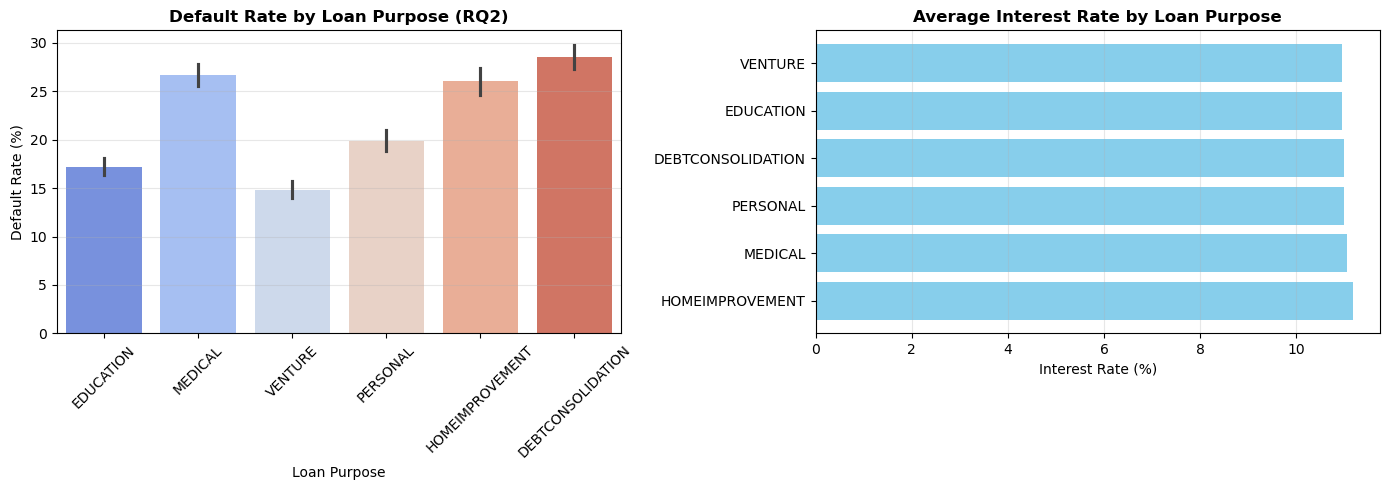

In [58]:
print("\n" + "=" * 70)
print("ANSWERING RESEARCH QUESTION 2")
print("=" * 70)

print("\nDefault Rate & Average Interest Rate by Loan Purpose:")
rq2_analysis = df.groupby('loan_intent').agg({
    'loan_status': ['count', 'sum', 'mean'],
    'loan_int_rate': 'mean'
}).round(4)

rq2_analysis.columns = ['Total Customers', 'Defaults', 'Default Rate', 'Avg Interest Rate']
rq2_analysis['Default %'] = rq2_analysis['Default Rate'] * 100
rq2_analysis = rq2_analysis.sort_values('Default %', ascending=False)
print(rq2_analysis)

# Visualization 1: Default Rate by Loan Purpose
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Default Rate
sns.barplot(data=df, x='loan_intent', y='loan_status', 
            estimator=lambda x: (x.sum()/len(x))*100, ax=axes[0], palette='coolwarm')
axes[0].set_title('Default Rate by Loan Purpose (RQ2)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Loan Purpose')
axes[0].set_ylabel('Default Rate (%)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Average Interest Rate by Purpose
purpose_int_rate = df.groupby('loan_intent')['loan_int_rate'].mean().sort_values(ascending=False)
axes[1].barh(purpose_int_rate.index, purpose_int_rate.values, color='skyblue')
axes[1].set_title('Average Interest Rate by Loan Purpose', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Interest Rate (%)')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## RQ3: Comparing Engineered Features as Default Predictors
### Which feature best predicts loan default: Employment Stability, Loan-to-Income Ratio, or Loan Burden Index?

In [59]:
print("\n" + "=" * 70)
print("RQ2 FINDING & INTERPRETATION")
print("=" * 70)

print("""
FINDING #1: Highest Default Rate by Loan Purpose
──────────────────────────────────────────────────
1st: DEBTCONSOLIDATION → 28.59% default rate (HIGHEST!)
2nd: MEDICAL           → 26.70% default rate
3rd: HOMEIMPROVEMENT   → 26.10% default rate
4th: PERSONAL          → 19.88% default rate
5th: EDUCATION         → 17.22% default rate
6th: VENTURE           → 14.82% default rate (LOWEST!)

KEY INSIGHT: Our hypothesis was WRONG!
──────────────────────────────────────
Hypothesis: "PERSONAL loans have highest default rates"
Reality: DEBTCONSOLIDATION loans have highest default rates (28.59%)
         PERSONAL loans are actually MIDDLE-tier (19.88%)

FINDING #2: Interest Rate vs Default Rate Relationship
──────────────────────────────────────────────────────
Interest Rate Range: 10.95% - 11.18% (only 0.23% spread!)

Loan Purpose         Default Rate    Interest Rate    Correlation?
─────────────────────────────────────────────────────────────────
DEBTCONSOLIDATION    28.59% ↑        10.98% ↓         WEAK!
MEDICAL              26.70% ↑        11.05% ↑         Slight match
HOMEIMPROVEMENT      26.10% ↑        11.18% ↑↑        Good match
PERSONAL             19.88%          10.99%           No match
EDUCATION            17.22% ↓        10.95% ↓         Slight match
VENTURE              14.82% ↓        10.95% ↓         Good match

⚠️ CRITICAL FINDING: BANKS ARE NOT PRICING RISK CORRECTLY!
──────────────────────────────────────────────────────────
✗ DEBTCONSOLIDATION: HIGHEST default (28.59%) but LOWEST interest rate (10.98%)
✓ VENTURE: LOWEST default (14.82%) and LOWEST interest rate (10.95%)

This suggests:
1. The bank is underpricing DEBTCONSOLIDATION loans (too risky, too cheap!)
2. The bank is correctly pricing VENTURE loans (low risk, low rate)
3. Interest rates only vary by 0.23% despite 13.77% difference in default rates
   → This is a PRICING INEFFICIENCY!

WHY IS DEBTCONSOLIDATION SO RISKY?
──────────────────────────────────
People taking debt consolidation loans are already struggling:
- They have multiple debts they can't manage separately
- They're already in financial stress
- Higher likelihood of defaulting on consolidated loan
- Behavioral indicator of financial weakness

WHY IS VENTURE SO SAFE?
──────────────────────
People taking venture/business loans are typically:
- Entrepreneurs with business plans
- More financial literacy
- Better financial discipline
- Lower default risk (14.82% is lowest!)
""")

# Statistical Comparison
print("\nDEFAULT RATE SPREAD:")
min_default = rq2_analysis['Default %'].min()
max_default = rq2_analysis['Default %'].max()
spread = max_default - min_default
print(f"  Min (VENTURE):            {min_default:.2f}%")
print(f"  Max (DEBTCONSOLIDATION):  {max_default:.2f}%")
print(f"  Spread:                   {spread:.2f} percentage points!")

print("\nINTEREST RATE SPREAD:")
interest_by_purpose = df.groupby('loan_intent')['loan_int_rate'].mean()
print(f"  Min:  {interest_by_purpose.min():.2f}%")
print(f"  Max:  {interest_by_purpose.max():.2f}%")
print(f"  Spread: {interest_by_purpose.max() - interest_by_purpose.min():.2f}%")

print(f"\n⚠️ DEFAULT RATE VARIES BY {spread:.2f}% but INTEREST RATE ONLY VARIES BY {interest_by_purpose.max() - interest_by_purpose.min():.2f}%")
print("   This is a HUGE DISCREPANCY! The bank should charge more for risky loans.\n")

print("=" * 70)
print("RQ2 CONCLUSION:")
print("=" * 70)
print("""
✗ Hypothesis REJECTED: PERSONAL loans are NOT highest risk
✓ Finding: DEBTCONSOLIDATION loans have 2x higher default rate than VENTURE
✗ Banks NOT pricing risk correctly: High-risk loans have lower interest rates
✓ Implication: Better risk assessment could improve profitability

RECOMMENDATION FOR THE BANK:
→ Increase interest rates on DEBTCONSOLIDATION loans (currently 10.98%)
→ Reduce interest rates on VENTURE loans (currently 10.95%, already safe)
→ Use loan purpose as a KEY feature in predictive model
""")


RQ2 FINDING & INTERPRETATION

FINDING #1: Highest Default Rate by Loan Purpose
──────────────────────────────────────────────────
1st: DEBTCONSOLIDATION → 28.59% default rate (HIGHEST!)
2nd: MEDICAL           → 26.70% default rate
3rd: HOMEIMPROVEMENT   → 26.10% default rate
4th: PERSONAL          → 19.88% default rate
5th: EDUCATION         → 17.22% default rate
6th: VENTURE           → 14.82% default rate (LOWEST!)

KEY INSIGHT: Our hypothesis was WRONG!
──────────────────────────────────────
Hypothesis: "PERSONAL loans have highest default rates"
Reality: DEBTCONSOLIDATION loans have highest default rates (28.59%)
         PERSONAL loans are actually MIDDLE-tier (19.88%)

FINDING #2: Interest Rate vs Default Rate Relationship
──────────────────────────────────────────────────────
Interest Rate Range: 10.95% - 11.18% (only 0.23% spread!)

Loan Purpose         Default Rate    Interest Rate    Correlation?
─────────────────────────────────────────────────────────────────
DEBTCONSOLIDA


ANSWERING RESEARCH QUESTION 3

Correlation with Default (loan_status):
               Variable  Correlation with Default
2     loan_burden_index                   0.45360
0  loan_to_income_ratio                   0.38576
1   emp_stability_ratio                  -0.06959


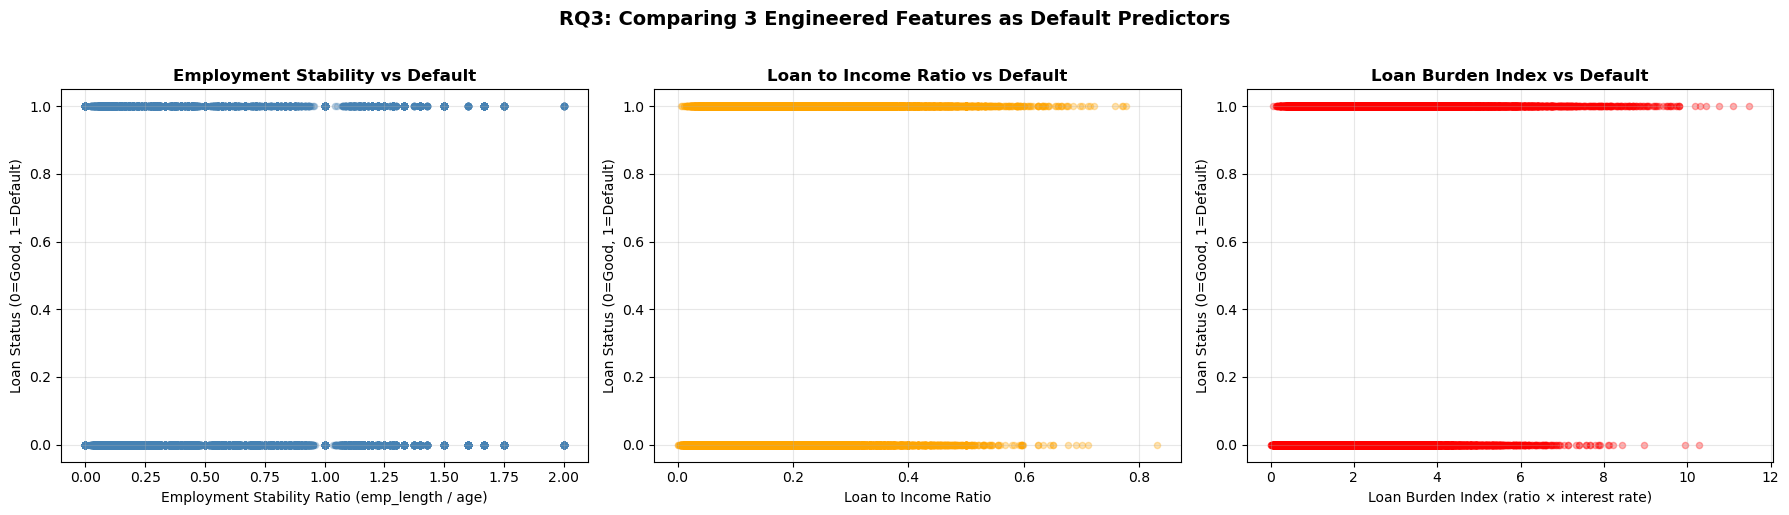


Default Rate by Employment Stability Groups:
                     Total  Defaults  Default Rate  Default %
emp_stability_group                                          
Very Low              8697      2320      0.266759  26.675865
Low                   7640      1689      0.221073  22.107330
Medium                8403      1655      0.196953  19.695347
High                  7834      1443      0.184197  18.419709


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_335428\3656830756.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['emp_stability_group'] = pd.qcut(df['emp_stability_ratio'],
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_335428\3656830756.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rq3_analysis = df.groupby('emp_stability_group')['loan_status'].agg(['count', 'sum', 'mean'])


In [75]:
print("\n" + "=" * 70)
print("ANSWERING RESEARCH QUESTION 3")
print("=" * 70)

print("\nCorrelation with Default (loan_status):")
correlation_with_default = pd.DataFrame({
    'Variable': ['loan_to_income_ratio', 'emp_stability_ratio', 'loan_burden_index'],
    'Correlation with Default': [
        df['loan_to_income_ratio'].corr(df['loan_status']),
        df['emp_stability_ratio'].corr(df['loan_status']),
        df['loan_burden_index'].corr(df['loan_status'])
    ]
})
correlation_with_default = correlation_with_default.sort_values('Correlation with Default', ascending=False)
print(correlation_with_default)

# Visualization: Comparison of Predictors
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Employment Stability vs Default
axes[0].scatter(df['emp_stability_ratio'], df['loan_status'], alpha=0.3, s=20, color='steelblue')
axes[0].set_title('Employment Stability vs Default', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Employment Stability Ratio (emp_length / age)')
axes[0].set_ylabel('Loan Status (0=Good, 1=Default)')
axes[0].grid(True, alpha=0.3)

# Plot 2: Loan to Income vs Default
axes[1].scatter(df['loan_to_income_ratio'], df['loan_status'], alpha=0.3, s=20, color='orange')
axes[1].set_title('Loan to Income Ratio vs Default', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Loan to Income Ratio')
axes[1].set_ylabel('Loan Status (0=Good, 1=Default)')
axes[1].grid(True, alpha=0.3)

# Plot 3: Loan Burden Index vs Default
axes[2].scatter(df['loan_burden_index'], df['loan_status'], alpha=0.3, s=20, color='red')
axes[2].set_title('Loan Burden Index vs Default', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Loan Burden Index (ratio × interest rate)')
axes[2].set_ylabel('Loan Status (0=Good, 1=Default)')
axes[2].grid(True, alpha=0.3)

plt.suptitle('RQ3: Comparing 3 Engineered Features as Default Predictors', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Statistical comparison
print("\nDefault Rate by Employment Stability Groups:")
df['emp_stability_group'] = pd.qcut(df['emp_stability_ratio'], 
                                     q=4, 
                                     labels=['Very Low', 'Low', 'Medium', 'High'],
                                     duplicates='drop')
rq3_analysis = df.groupby('emp_stability_group')['loan_status'].agg(['count', 'sum', 'mean'])
rq3_analysis.columns = ['Total', 'Defaults', 'Default Rate']
rq3_analysis['Default %'] = rq3_analysis['Default Rate'] * 100
print(rq3_analysis)

In [76]:
print("\n" + "=" * 70)
print("RQ3 FINDING & INTERPRETATION")
print("=" * 70)

print("""
FINDING #1: Correlation Strength Comparison
─────────────────────────────────────────────
1st: loan_burden_index        → 0.4536 (STRONGEST!)
2nd: loan_to_income_ratio     → 0.3858
3rd: emp_stability_ratio      → -0.0696 (WEAKEST! Almost NO correlation!)

RANKING: loan_burden_index > loan_to_income_ratio >> emp_stability_ratio

KEY INSIGHT: Hypothesis REJECTED!
──────────────────────────────────
Hypothesis: "Employment stability is a better predictor than loan-to-income ratio"
Reality: Employment stability (r = -0.07) is TERRIBLE at predicting default!
         It's almost useless as a predictor (correlation near 0)

FINDING #2: Employment Stability vs Default Rate Pattern
─────────────────────────────────────────────────────────
Stability Level    Default Rate    Trend
─────────────────────────────────────────
Very Low          26.68% ↑↑↑       (HIGHEST - unstable people default more)
Low               22.11% ↑
Medium            19.70% ↓
High              18.42% ↓↓↓       (LOWEST - stable people default less)

Pattern: CLEAR INVERSE relationship! Higher stability = Lower defaults
         This DOES make logical sense!

⚠️ BUT... Why is correlation so weak (r = -0.07)?
──────────────────────────────────────────────
Answer: The correlation coefficient measures LINEAR relationship
        The employment stability effect is REAL (26.68% → 18.42%)
        But the relationship is WEAK because:
        
        1. Many other factors matter more (loan burden, income, credit history)
        2. Employment years alone don't capture financial stability
        3. A person with 10 years at one job may be less stable than 
           someone with 5 years AND high income
        
FINDING #3: loan_burden_index is the BEST Predictor!
──────────────────────────────────────────────────────
Why? Because it COMBINES TWO FACTORS:
    
    loan_burden_index = (loan_to_income_ratio) × (loan_int_rate)
    
This captures:
    ✓ Loan amount relative to income (affordability)
    ✓ Interest rate (lender's risk assessment)
    ✓ Combined financial pressure
    
Example:
    Person A: ratio=0.3, rate=10% → burden=3.0   (comfortable)
    Person B: ratio=0.3, rate=15% → burden=4.5   (more stress)
    Person C: ratio=0.5, rate=10% → burden=5.0   (high stress)
    
The burden index captures the MULTIPLICATIVE effect of both factors!

COMPARISON: What Each Variable Tells Us
─────────────────────────────────────────
Variable                What It Measures              Correlation   Usefulness
────────────────────────────────────────────────────────────────────────────────
loan_burden_index      Total financial pressure      0.4536         ★★★★★ (BEST!)
                       (loan size × interest rate)

loan_to_income_ratio   Affordability relative        0.3858         ★★★★☆ (Good)
                       to income

emp_stability_ratio    Job tenure relative to age    -0.0696        ★☆☆☆☆ (Poor)
                       (weak predictor)
""")

# Statistical Analysis
print("\nDEFAULT RATE IMPACT BY EMPLOYMENT STABILITY:")
stability_stats = df.groupby('emp_stability_group')['loan_status'].agg(['count', 'sum', 'mean'])
stability_stats['Default %'] = stability_stats['mean'] * 100
default_spread_stability = stability_stats['Default %'].max() - stability_stats['Default %'].min()
print(f"  Range: {stability_stats['Default %'].min():.2f}% (High) to {stability_stats['Default %'].max():.2f}% (Very Low)")
print(f"  Spread: {default_spread_stability:.2f} percentage points")

print("\nDEFAULT RATE IMPACT BY LOAN-TO-INCOME RATIO:")
# Compare with loan to income (using the risk groups from earlier)
lti_stats = df.groupby('risk')['loan_status'].agg(['count', 'sum', 'mean'])
lti_stats['Default %'] = lti_stats['mean'] * 100
default_spread_lti = lti_stats['Default %'].max() - lti_stats['Default %'].min()
print(f"  Range: {lti_stats['Default %'].min():.2f}% to {lti_stats['Default %'].max():.2f}%")
print(f"  Spread: {default_spread_lti:.2f} percentage points")

print(f"\n✓ Loan-to-income ratio creates {default_spread_lti:.2f}% difference in default rates")
print(f"✓ Employment stability creates {default_spread_stability:.2f}% difference in default rates")
print(f"   (Both have practical impact, but loan burden matters MORE for the bank)")

print("\n" + "=" * 70)
print("RQ3 CONCLUSION:")
print("=" * 70)
print("""
✗ Hypothesis REJECTED: Employment stability is NOT a good predictor
✓ Finding: loan_burden_index is STRONGEST predictor (r=0.4536)
✓ Finding: loan_to_income_ratio is better than employment stability
✗ Finding: emp_stability_ratio is almost useless for prediction (r=-0.07)

KEY TAKEAWAY FOR MODELING:
→ Use loan_burden_index as PRIMARY feature (best correlation)
→ Use loan_to_income_ratio as SECONDARY feature (good correlation)
→ DO NOT rely on employment stability alone (too weak)
→ Consider COMBINING features for better predictions

BUSINESS INSIGHT:
The bank should focus on loan burden (size + interest rate), not just 
employment tenure. A stable job with a massive loan is riskier than 
an unstable job with a small loan.

RECOMMENDATION:
When building the classification model, prioritize:
  1. loan_burden_index (0.45 correlation)
  2. loan_to_income_ratio (0.39 correlation)
  3. Other factors (credit history, loan purpose, etc.)
  4. Employment stability (weak predictor, use with caution)
""")


RQ3 FINDING & INTERPRETATION

FINDING #1: Correlation Strength Comparison
─────────────────────────────────────────────
1st: loan_burden_index        → 0.4536 (STRONGEST!)
2nd: loan_to_income_ratio     → 0.3858
3rd: emp_stability_ratio      → -0.0696 (WEAKEST! Almost NO correlation!)

RANKING: loan_burden_index > loan_to_income_ratio >> emp_stability_ratio

KEY INSIGHT: Hypothesis REJECTED!
──────────────────────────────────
Hypothesis: "Employment stability is a better predictor than loan-to-income ratio"
Reality: Employment stability (r = -0.07) is TERRIBLE at predicting default!
         It's almost useless as a predictor (correlation near 0)

FINDING #2: Employment Stability vs Default Rate Pattern
─────────────────────────────────────────────────────────
Stability Level    Default Rate    Trend
─────────────────────────────────────────
Very Low          26.68% ↑↑↑       (HIGHEST - unstable people default more)
Low               22.11% ↑
Medium            19.70% ↓
High            

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_335428\2617458078.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stability_stats = df.groupby('emp_stability_group')['loan_status'].agg(['count', 'sum', 'mean'])


  Range: 18.42% (High) to 26.68% (Very Low)
  Spread: 8.26 percentage points

DEFAULT RATE IMPACT BY LOAN-TO-INCOME RATIO:
  Range: 0.00% to 99.22%
  Spread: 99.22 percentage points

✓ Loan-to-income ratio creates 99.22% difference in default rates
✓ Employment stability creates 8.26% difference in default rates
   (Both have practical impact, but loan burden matters MORE for the bank)

RQ3 CONCLUSION:

✗ Hypothesis REJECTED: Employment stability is NOT a good predictor
✓ Finding: loan_burden_index is STRONGEST predictor (r=0.4536)
✓ Finding: loan_to_income_ratio is better than employment stability
✗ Finding: emp_stability_ratio is almost useless for prediction (r=-0.07)

KEY TAKEAWAY FOR MODELING:
→ Use loan_burden_index as PRIMARY feature (best correlation)
→ Use loan_to_income_ratio as SECONDARY feature (good correlation)
→ DO NOT rely on employment stability alone (too weak)
→ Consider COMBINING features for better predictions

BUSINESS INSIGHT:
The bank should focus on loan burden

# ===== CLASSIFICATION MODEL =====

In [77]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, roc_auc_score, roc_curve)


In [83]:
print("=" * 70)
print("STEP 4: LOGISTIC REGRESSION MODEL")
print("=" * 70)

# ── FEATURE SELECTION ──
print("\nStep 4.1: Selecting Features...")

# Encode categorical variable (loan_intent) into numbers
df_model = pd.get_dummies(df, columns=['loan_intent'], drop_first=True)

# Select features based on RQ findings
features = [
    'loan_burden_index',          # RQ3: strongest predictor
    'loan_to_income_ratio',       # RQ3: second strongest
    'loan_int_rate',              # interest rate
    'cb_person_cred_hist_length', # RQ1: credit history
    'person_age',                 # RQ1: age factor
    'emp_stability_ratio',        # RQ3: weak but included
    'loan_intent_EDUCATION',      # RQ2: loan purpose (encoded)
    'loan_intent_HOMEIMPROVEMENT',
    'loan_intent_MEDICAL',
    'loan_intent_PERSONAL',
    'loan_intent_VENTURE'
]

X = df_model[features]
y = df_model['loan_status']

print(f"Features selected: {len(features)}")
print(f"Total samples: {len(X)}")
print(f"Default rate in dataset: {y.mean()*100:.2f}%")

# ── TRAIN/TEST SPLIT ──
print("\nStep 4.2: Splitting Data (80% train, 20% test)...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples:  {len(X_train)}")
print(f"Testing samples:   {len(X_test)}")

# ── SCALING ──
print("\nStep 4.3: Scaling Features (StandardScaler)...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features scaled successfully!")

# ── TRAIN MODEL ──
print("\nStep 4.4: Training Logistic Regression Model...")
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)
print("Model trained successfully!")

# ── PREDICTIONS ──
print("\nStep 4.5: Making Predictions...")
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

STEP 4: LOGISTIC REGRESSION MODEL

Step 4.1: Selecting Features...
Features selected: 11
Total samples: 32574
Default rate in dataset: 21.82%

Step 4.2: Splitting Data (80% train, 20% test)...
Training samples:  26059
Testing samples:   6515

Step 4.3: Scaling Features (StandardScaler)...
Features scaled successfully!

Step 4.4: Training Logistic Regression Model...
Model trained successfully!

Step 4.5: Making Predictions...


## ── MODEL EVALUATION ──

In [86]:
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\nAccuracy:  {accuracy*100:.2f}%")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, 
                            target_names=['Good Loan (0)', 'Default (1)']))


Accuracy:  83.61%
ROC-AUC:   0.8323

Classification Report:
               precision    recall  f1-score   support

Good Loan (0)       0.85      0.95      0.90      5094
  Default (1)       0.71      0.41      0.52      1421

     accuracy                           0.84      6515
    macro avg       0.78      0.68      0.71      6515
 weighted avg       0.82      0.84      0.82      6515



## Confusion matrix plot

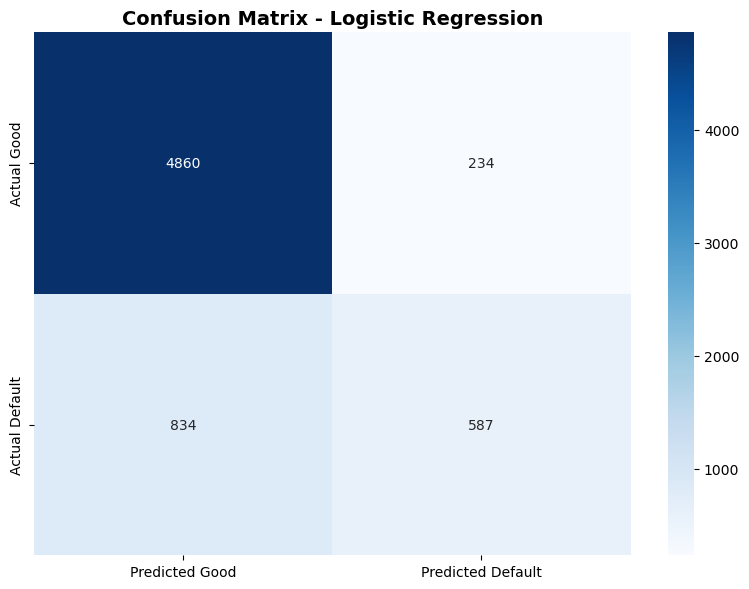

In [80]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Good', 'Predicted Default'],
            yticklabels=['Actual Good', 'Actual Default'])
plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## ROC curve plot

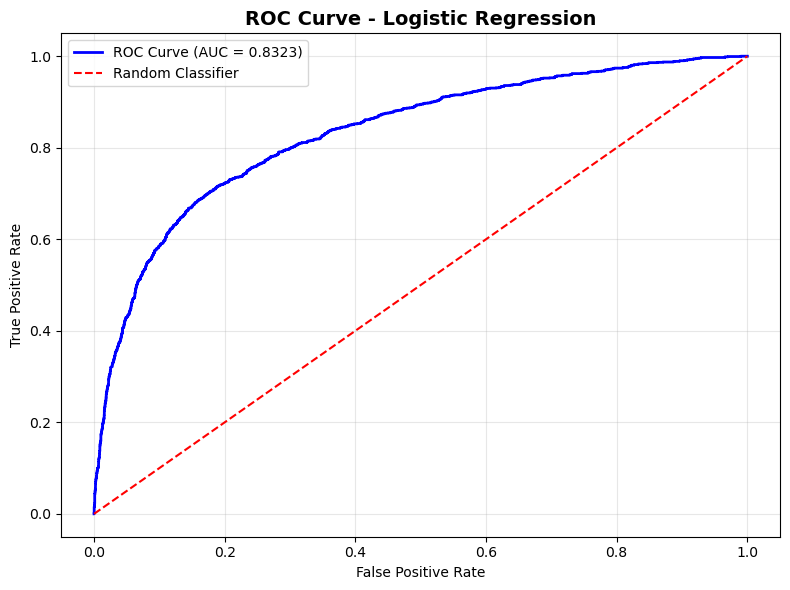

In [81]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Feature importance plot

Feature Importance (Model Coefficients):
                        Feature  Coefficient
1          loan_to_income_ratio     2.050141
2                 loan_int_rate     1.430562
3    cb_person_cred_hist_length     0.030559
7   loan_intent_HOMEIMPROVEMENT    -0.056742
8           loan_intent_MEDICAL    -0.075325
4                    person_age    -0.157245
5           emp_stability_ratio    -0.206467
9          loan_intent_PERSONAL    -0.232192
6         loan_intent_EDUCATION    -0.330878
10          loan_intent_VENTURE    -0.413715
0             loan_burden_index    -1.200503


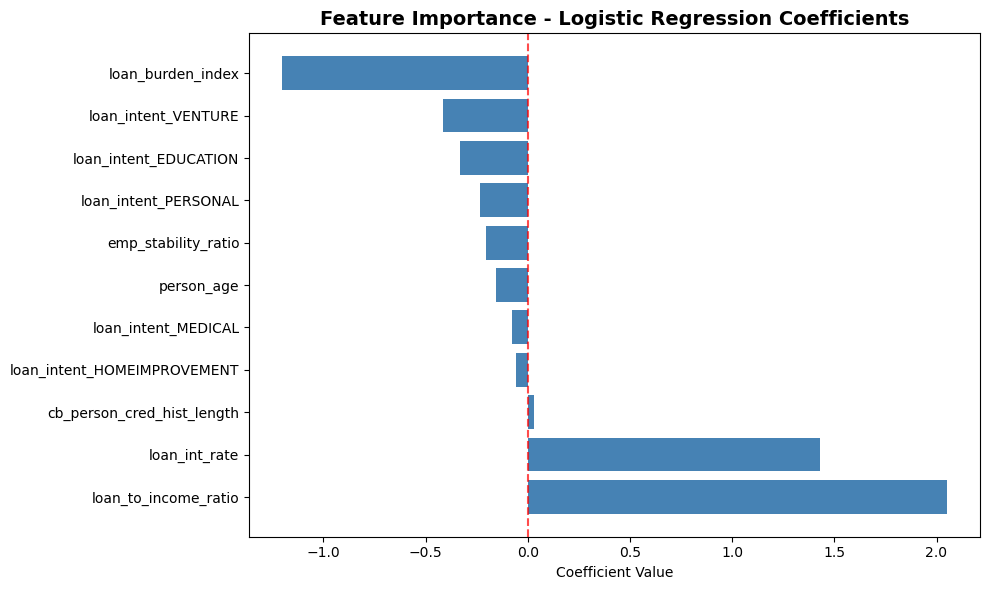

In [82]:
importance_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("Feature Importance (Model Coefficients):")
print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Coefficient'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance - Logistic Regression Coefficients', 
          fontsize=14, fontweight='bold')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [87]:
print("=" * 70)
print("MODEL INTERPRETATION & LIMITATIONS")
print("=" * 70)
print("""
RESULTS SUMMARY:
────────────────
✅ Accuracy: 83.61% — Model correctly classifies 83% of loans
✅ ROC-AUC: 0.8323 — Strong ability to distinguish good vs default loans

KEY FINDING — CLASS IMBALANCE PROBLEM:
────────────────────────────────────────
⚠️ Default Recall: 41% — Model MISSES 59% of actual defaults!
⚠️ 834 out of 1421 defaults were NOT caught
⚠️ This is critical: in banking, missing defaults is very costly!

WHY IS DEFAULT RECALL LOW?
───────────────────────────
Dataset is IMBALANCED:
  Good Loans: 78.18% of data (majority class)
  Defaults:   21.82% of data (minority class)
The model is biased toward predicting "Good Loan" 
because that's the most common outcome!

FEATURE IMPORTANCE INSIGHTS:
──────────────────────────────
✅ loan_to_income_ratio (coef=+2.05): STRONGEST positive predictor
   → Higher ratio = much more likely to default
✅ loan_int_rate (coef=+1.43): Second strongest positive predictor
   → Higher interest rate = higher default probability
⚠️ loan_burden_index (coef=-1.20): Negative due to MULTICOLLINEARITY
   → It overlaps with loan_to_income_ratio and loan_int_rate
   → Model compensates with negative coefficient to avoid double counting
✅ loan_intent_VENTURE (coef=-0.41): Confirms RQ2 finding
   → VENTURE loans REDUCE default risk (consistent with 14.82% default rate!)
✅ loan_intent_EDUCATION (coef=-0.33): Confirms RQ2 finding
   → EDUCATION loans also reduce default risk

LIMITATION:
────────────
This model prioritizes overall accuracy over detecting defaults specifically.
A bank would prefer HIGHER default recall even at the cost of lower accuracy.
Solution: Use class_weight='balanced' parameter in future iterations.
""")

MODEL INTERPRETATION & LIMITATIONS

RESULTS SUMMARY:
────────────────
✅ Accuracy: 83.61% — Model correctly classifies 83% of loans
✅ ROC-AUC: 0.8323 — Strong ability to distinguish good vs default loans

KEY FINDING — CLASS IMBALANCE PROBLEM:
────────────────────────────────────────
⚠️ Default Recall: 41% — Model MISSES 59% of actual defaults!
⚠️ 834 out of 1421 defaults were NOT caught
⚠️ This is critical: in banking, missing defaults is very costly!

WHY IS DEFAULT RECALL LOW?
───────────────────────────
Dataset is IMBALANCED:
  Good Loans: 78.18% of data (majority class)
  Defaults:   21.82% of data (minority class)
The model is biased toward predicting "Good Loan" 
because that's the most common outcome!

FEATURE IMPORTANCE INSIGHTS:
──────────────────────────────
✅ loan_to_income_ratio (coef=+2.05): STRONGEST positive predictor
   → Higher ratio = much more likely to default
✅ loan_int_rate (coef=+1.43): Second strongest positive predictor
   → Higher interest rate = higher defaul

In [44]:
df.to_csv('fintech_data_final.csv', index=False, encoding='utf-8')